# SHL Hiring Assessment 2026 — Grammar Scoring from Speech

## Objective

The objective is to predict a continuous grammar score (0–5) from approximately 45–60 second spoken audio recordings.

The training dataset contains 769 labeled audio recordings and the test dataset contains 216 recordings.

## Approach

The solution follows an audio-based machine learning pipeline:

1. Load and validate the training and test metadata.
2. Verify audio properties and filename-to-audio matching.
3. Extract acoustic speech features using Librosa.
4. Extract additional fast prosodic/speech-activity features.
5. Train and compare multiple regression models.
6. Evaluate models using 5-fold cross-validation with RMSE and Pearson correlation.
7. Select Extra Trees Regression as the final model.
8. Generate out-of-fold predictions and apply linear calibration.
9. Train the final model on all available training data.
10. Generate predictions for the test set and create the final submission.

## Final Feature Set

The final model uses 51 acoustic and speech-activity features, including:

- MFCC statistics
- Chroma statistics
- Mel-spectrogram statistics
- Spectral centroid
- Spectral bandwidth
- Spectral contrast
- Zero-crossing statistics
- RMS energy statistics
- Duration
- Speech activity / silence features
- Energy dynamics

## Model Selection

Several regression approaches were evaluated using 5-fold cross-validation.

The final selected model was Extra Trees Regressor because it produced the strongest validation performance among the tested models.

## Validation

Final out-of-fold performance before calibration:

- RMSE: 0.7634
- Pearson correlation: 0.7894

A simple linear calibration learned from out-of-fold predictions improved RMSE to:

- **Calibrated RMSE: 0.7601**
- **Pearson correlation: 0.7894**

The final model was then trained on the complete training dataset and used to generate predictions for the 216 test recordings.

## Data Exploration

The training dataset contains 769 labeled recordings.

Audio files were verified to be mono 16 kHz WAV files. Filename matching was checked between the metadata and audio directories, with no missing or extra training/test audio files.

The target grammar scores range from 0 to 5.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import pandas as pd
import os

DATA_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load CSV files
train_df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))
sample_df = pd.read_csv(os.path.join(DATA_PATH, "sample_submission.csv"))

# Basic shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_df.columns.tolist())

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)

Train columns:
['filename', 'label']

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']


In [2]:
print("===== TRAIN =====")
display(train_df.head(10))

print("\n===== TEST =====")
display(test_df.head(10))

print("\n===== SAMPLE SUBMISSION =====")
display(sample_df.head(10))

===== TRAIN =====


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0
5,audio_639.wav,2.5
6,audio_703.wav,2.0
7,audio_509.wav,3.0
8,audio_672.wav,4.0
9,audio_344.wav,4.0



===== TEST =====


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1
5,audio_161.wav,-1
6,audio_215.wav,-1
7,audio_213.wav,-1
8,audio_11.wav,-1
9,audio_155.wav,-1



===== SAMPLE SUBMISSION =====


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1
5,audio_278.wav,-1
6,audio_1212.wav,-1
7,audio_178.wav,-1
8,audio_542.wav,-1
9,audio_248.wav,-1


In [3]:
print("===== TRAIN LABELS =====")
print(train_df["label"].describe())

print("\nUnique labels:")
print(sorted(train_df["label"].unique()))

print("\nLabel counts:")
print(train_df["label"].value_counts().sort_index())

===== TRAIN LABELS =====
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

Unique labels:
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Label counts:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


In [4]:
print("Missing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

print("\nMissing values in sample submission:")
print(sample_df.isnull().sum())

Missing values in train:
filename    0
label       0
dtype: int64

Missing values in test:
filename    0
label       0
dtype: int64

Missing values in sample submission:
filename    0
label       0
dtype: int64


In [5]:
print("Minimum label:", train_df["label"].min())
print("Maximum label:", train_df["label"].max())

print("\nAll unique labels:")
print(sorted(train_df["label"].unique()))

print("\nNumber of samples for each label:")
print(train_df["label"].value_counts().sort_index())

Minimum label: 0.0
Maximum label: 5.0

All unique labels:
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Number of samples for each label:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


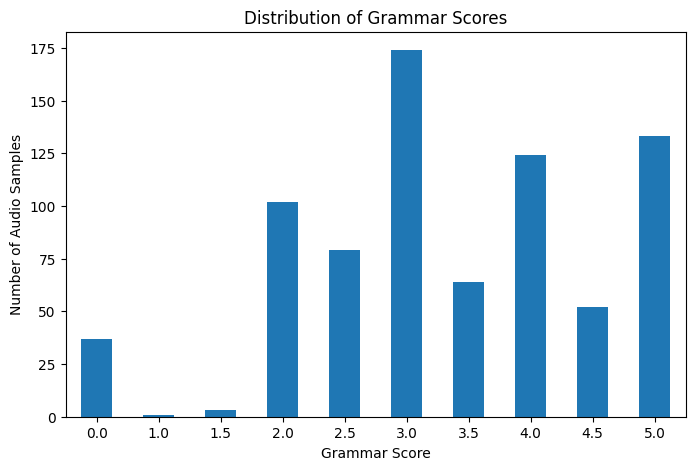

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

train_df["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Grammar Scores")
plt.xlabel("Grammar Score")
plt.ylabel("Number of Audio Samples")
plt.xticks(rotation=0)
plt.show()

In [7]:
import os

TRAIN_AUDIO_PATH = os.path.join(DATA_PATH, "train")
TEST_AUDIO_PATH = os.path.join(DATA_PATH, "test")

train_audio_files = set(os.listdir(TRAIN_AUDIO_PATH))
test_audio_files = set(os.listdir(TEST_AUDIO_PATH))

train_csv_files = set(train_df["filename"])
test_csv_files = set(test_df["filename"])

print("Train audio files:", len(train_audio_files))
print("Train CSV filenames:", len(train_csv_files))

print("Test audio files:", len(test_audio_files))
print("Test CSV filenames:", len(test_csv_files))

print("\nTrain CSV files missing from audio folder:",
      len(train_csv_files - train_audio_files))

print("Test CSV files missing from audio folder:",
      len(test_csv_files - test_audio_files))

print("\nAudio files not listed in train CSV:",
      len(train_audio_files - train_csv_files))

print("Audio files not listed in test CSV:",
      len(test_audio_files - test_csv_files))

Train audio files: 769
Train CSV filenames: 769
Test audio files: 216
Test CSV filenames: 216

Train CSV files missing from audio folder: 0
Test CSV files missing from audio folder: 0

Audio files not listed in train CSV: 0
Audio files not listed in test CSV: 0


In [8]:
import librosa
import os
import numpy as np

# Inspect first 10 training audio files
print("===== AUDIO FILE INSPECTION =====\n")

for filename in train_df["filename"].head(10):

    filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

    y, sr = librosa.load(filepath, sr=None, mono=False)

    if y.ndim == 1:
        channels = 1
        samples = len(y)
    else:
        channels = y.shape[0]
        samples = y.shape[1]

    duration = samples / sr

    print(f"File: {filename}")
    print(f"  Duration : {duration:.2f} seconds")
    print(f"  Sample rate: {sr} Hz")
    print(f"  Channels : {channels}")
    print(f"  Samples  : {samples}")
    print()

===== AUDIO FILE INSPECTION =====

File: audio_192.wav
  Duration : 60.51 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 968134

File: audio_436.wav
  Duration : 60.07 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 961195

File: audio_447.wav
  Duration : 60.07 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 961195

File: audio_126.wav
  Duration : 45.06 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 720960

File: audio_61.wav
  Duration : 45.30 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 724800

File: audio_639.wav
  Duration : 60.07 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 961195

File: audio_703.wav
  Duration : 52.16 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 834560

File: audio_509.wav
  Duration : 60.07 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 961195

File: audio_672.wav
  Duration : 60.07 seconds
  Sample rate: 16000 Hz
  Channels : 1
  Samples  : 961195

Fil

In [9]:
durations = []
sample_rates = []
channels_list = []

for filename in train_df["filename"]:

    filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

    y, sr = librosa.load(filepath, sr=None, mono=False)

    if y.ndim == 1:
        channels = 1
        samples = len(y)
    else:
        channels = y.shape[0]
        samples = y.shape[1]

    duration = samples / sr

    durations.append(duration)
    sample_rates.append(sr)
    channels_list.append(channels)

print("===== AUDIO DATASET SUMMARY =====")

print(f"Number of files: {len(durations)}")

print(f"\nDuration:")
print(f"  Minimum: {min(durations):.2f} sec")
print(f"  Maximum: {max(durations):.2f} sec")
print(f"  Mean   : {np.mean(durations):.2f} sec")

print(f"\nSample rates:")
print(set(sample_rates))

print(f"\nChannels:")
print(set(channels_list))

===== AUDIO DATASET SUMMARY =====
Number of files: 769

Duration:
  Minimum: 20.06 sec
  Maximum: 61.04 sec
  Mean   : 55.78 sec

Sample rates:
{16000}

Channels:
{1}


Filename: audio_192.wav
Sample rate: 16000
Duration: 60.508375 seconds


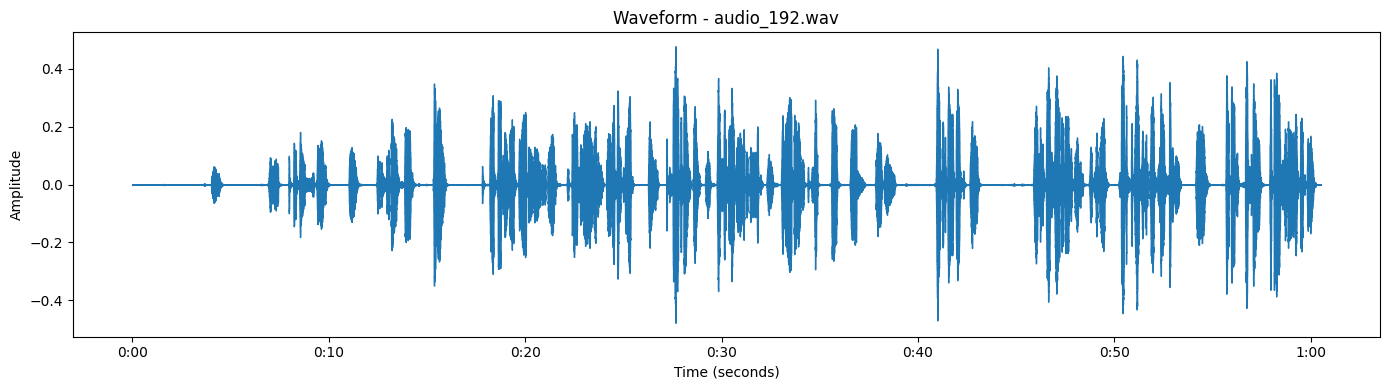

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Select one training audio file
filename = train_df.iloc[0]["filename"]
filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

# Load audio
y, sr = librosa.load(filepath, sr=None)

print("Filename:", filename)
print("Sample rate:", sr)
print("Duration:", len(y) / sr, "seconds")

# Create waveform
plt.figure(figsize=(14, 4))

librosa.display.waveshow(y, sr=sr)

plt.title(f"Waveform - {filename}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

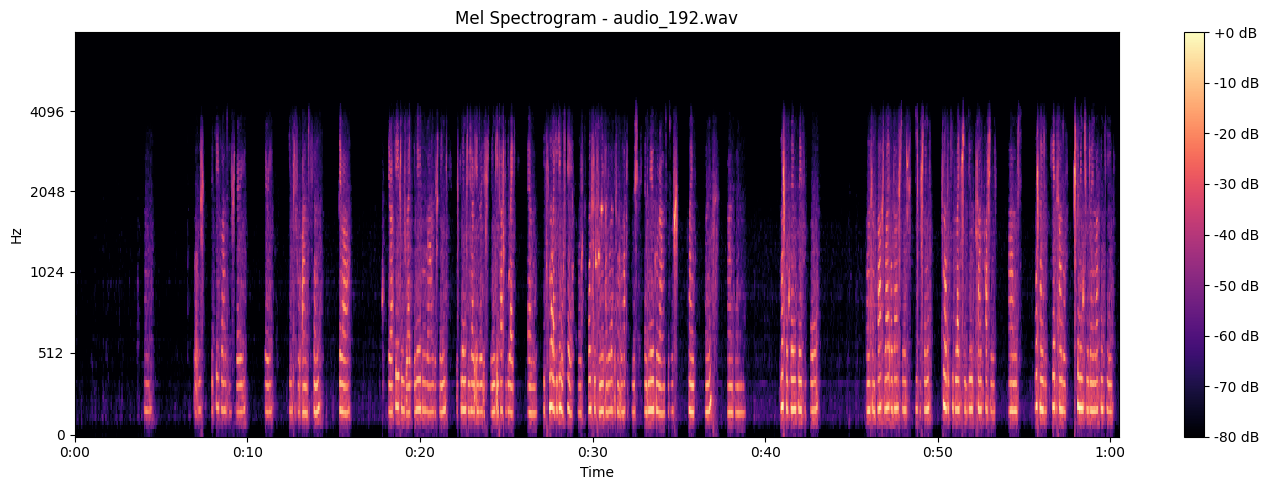

In [11]:
# Create Mel spectrogram

mel_spectrogram = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=8000
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    fmax=8000
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram - {filename}")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import librosa
import os

def extract_audio_features(filepath):
    """
    Extract statistical audio features from one WAV file.
    """

    y, sr = librosa.load(filepath, sr=16000, mono=True)

    features = {}

    # --------------------------------------------------
    # 1. MFCC
    # --------------------------------------------------
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    for i in range(mfcc.shape[0]):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # --------------------------------------------------
    # 2. Chroma
    # --------------------------------------------------
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)

    # --------------------------------------------------
    # 3. Mel Spectrogram
    # --------------------------------------------------
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=40
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    features["mel_mean"] = np.mean(mel_db)
    features["mel_std"] = np.std(mel_db)

    # --------------------------------------------------
    # 4. Spectral features
    # --------------------------------------------------
    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )

    spectral_contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr
    )

    zero_crossing = librosa.feature.zero_crossing_rate(y)

    rms = librosa.feature.rms(y=y)

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    features["spectral_contrast_mean"] = np.mean(spectral_contrast)
    features["spectral_contrast_std"] = np.std(spectral_contrast)

    features["zero_crossing_mean"] = np.mean(zero_crossing)
    features["zero_crossing_std"] = np.std(zero_crossing)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # --------------------------------------------------
    # 5. Duration
    # --------------------------------------------------
    features["duration"] = len(y) / sr

    return features

In [13]:
test_file = os.path.join(
    TRAIN_AUDIO_PATH,
    train_df.iloc[0]["filename"]
)

features = extract_audio_features(test_file)

print("Number of features:", len(features))

for name, value in features.items():
    print(f"{name}: {value:.4f}")

Number of features: 41
mfcc_1_mean: -403.8359
mfcc_1_std: 121.6292
mfcc_2_mean: 103.5763
mfcc_2_std: 68.0357
mfcc_3_mean: -14.2135
mfcc_3_std: 37.1004
mfcc_4_mean: 16.6736
mfcc_4_std: 21.8437
mfcc_5_mean: 7.0486
mfcc_5_std: 11.1922
mfcc_6_mean: -4.9996
mfcc_6_std: 14.0739
mfcc_7_mean: 5.8857
mfcc_7_std: 10.0868
mfcc_8_mean: -9.2689
mfcc_8_std: 11.2389
mfcc_9_mean: -8.6811
mfcc_9_std: 9.1751
mfcc_10_mean: -6.1113
mfcc_10_std: 7.0058
mfcc_11_mean: -11.9470
mfcc_11_std: 8.7552
mfcc_12_mean: -8.2262
mfcc_12_std: 6.8835
mfcc_13_mean: -6.2382
mfcc_13_std: 5.7470
chroma_mean: 0.4005
chroma_std: 0.3219
mel_mean: -60.5835
mel_std: 19.5928
spectral_centroid_mean: 979.4785
spectral_centroid_std: 399.5679
spectral_bandwidth_mean: 916.4721
spectral_bandwidth_std: 261.6206
spectral_contrast_mean: 19.2508
spectral_contrast_std: 7.2181
zero_crossing_mean: 0.0848
zero_crossing_std: 0.0535
rms_mean: 0.0318
rms_std: 0.0384
duration: 60.5084


In [14]:
from tqdm.auto import tqdm
import pandas as pd
import os

train_features = []

for filename in tqdm(train_df["filename"], desc="Extracting training features"):

    filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

    features = extract_audio_features(filepath)

    # Keep filename so we can match everything later
    features["filename"] = filename

    train_features.append(features)

# Convert to DataFrame
train_features_df = pd.DataFrame(train_features)

# Add target label
train_features_df = train_features_df.merge(
    train_df,
    on="filename",
    how="left"
)

print("Feature dataframe shape:", train_features_df.shape)

display(train_features_df.head())

Extracting training features:   0%|          | 0/769 [00:00<?, ?it/s]

Feature dataframe shape: (769, 43)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_bandwidth_std,spectral_contrast_mean,spectral_contrast_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std,duration,filename,label
0,-403.835907,121.629189,103.576340,68.035652,-14.213533,37.100353,16.673616,21.843693,7.048550,11.192187,...,261.620566,19.250808,7.218130,0.084768,0.053518,0.031786,0.038404,60.508375,audio_192.wav,3.0
1,-287.111023,81.685997,72.087601,56.021065,5.334722,46.173588,24.854349,37.073082,-13.109429,27.177183,...,495.435560,21.143370,6.091789,0.142977,0.127519,0.068651,0.055423,60.074688,audio_436.wav,3.0
2,-324.808197,86.514740,97.828194,59.010967,18.635786,30.665184,5.857049,28.117016,2.258683,18.588797,...,535.214385,19.391575,5.168069,0.146870,0.129777,0.054421,0.051533,60.074688,audio_447.wav,3.5
3,-489.320648,124.842316,111.792915,53.296013,0.751575,41.733730,33.133247,33.229671,8.309433,21.988724,...,392.434373,20.520750,5.464585,0.059477,0.036870,0.013778,0.012183,45.060000,audio_126.wav,2.0
4,-483.865997,159.520401,51.975899,58.754555,-21.642136,44.306683,31.146597,36.615963,-11.265674,24.949566,...,442.415960,20.517873,6.097255,0.169988,0.128430,0.009330,0.008970,45.300000,audio_61.wav,2.0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Separate features and target
X = train_features_df.drop(columns=["filename", "label"])
y = train_features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (769, 41)
y shape: (769,)


In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))

Training samples: 615
Validation samples: 154


In [17]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [18]:
# Predictions
y_train_pred = rf_model.predict(X_train)
y_valid_pred = rf_model.predict(X_valid)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))

# Pearson correlation
train_pearson = pearsonr(y_train, y_train_pred)[0]
valid_pearson = pearsonr(y_valid, y_valid_pred)[0]

print("===== BASELINE RESULTS =====")

print(f"Training RMSE   : {train_rmse:.4f}")
print(f"Validation RMSE : {valid_rmse:.4f}")

print(f"\nTraining Pearson   : {train_pearson:.4f}")
print(f"Validation Pearson : {valid_pearson:.4f}")

===== BASELINE RESULTS =====
Training RMSE   : 0.3323
Validation RMSE : 0.7369

Training Pearson   : 0.9717
Validation Pearson : 0.8397


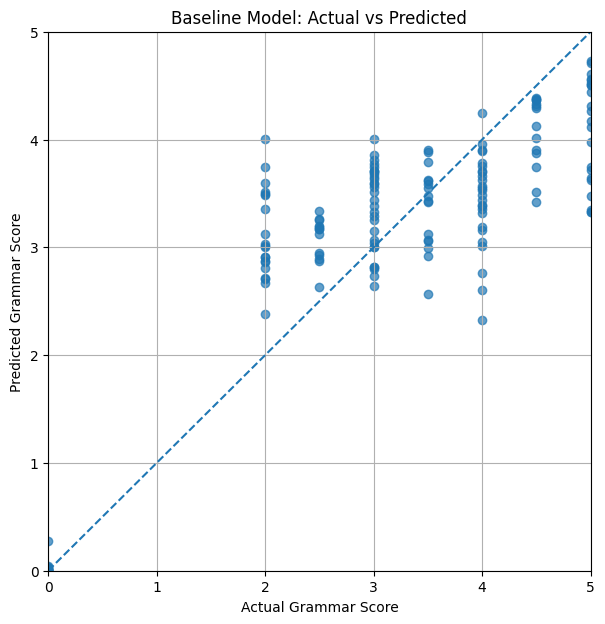

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_valid, y_valid_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [0, 5],
    [0, 5],
    linestyle="--"
)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Baseline Model: Actual vs Predicted")

plt.xlim(0, 5)
plt.ylim(0, 5)

plt.grid(True)
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("Top 20 most important features:")
display(importance_df.head(20))

Top 20 most important features:


,feature,importance
3,mfcc_2_std,0.140051
28,mel_mean,0.115963
5,mfcc_3_std,0.045336
26,chroma_mean,0.039931
36,zero_crossing_mean,0.034714
0,mfcc_1_mean,0.027668
33,spectral_bandwidth_std,0.027042
2,mfcc_2_mean,0.026894
13,mfcc_7_std,0.025957
4,mfcc_3_mean,0.025818


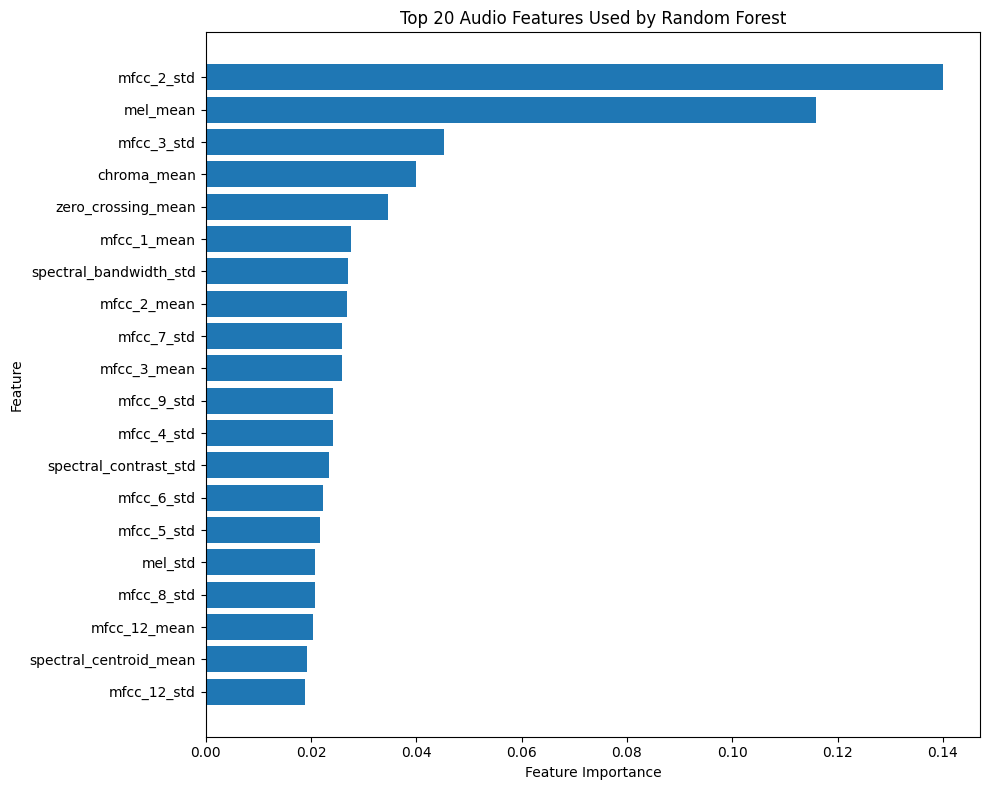

In [21]:
top_features = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Audio Features Used by Random Forest")

plt.tight_layout()
plt.show()

In [22]:
print(
    importance_df[
        importance_df["feature"] == "duration"
    ]
)

     feature  importance
40  duration    0.013083


In [23]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    # Create a fresh model for every fold
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )

    # Train
    model.fit(X_train_fold, y_train_fold)

    # Predict
    predictions = model.predict(X_valid_fold)

    # Metrics
    rmse = np.sqrt(
        mean_squared_error(y_valid_fold, predictions)
    )

    pearson = pearsonr(
        y_valid_fold,
        predictions
    )[0]

    cv_results.append({
        "fold": fold,
        "rmse": rmse,
        "pearson": pearson
    })

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

Fold 1: RMSE = 0.7313, Pearson = 0.8430
Fold 2: RMSE = 0.7459, Pearson = 0.7964
Fold 3: RMSE = 0.8372, Pearson = 0.7056
Fold 4: RMSE = 0.7752, Pearson = 0.7818
Fold 5: RMSE = 0.8572, Pearson = 0.6915


In [24]:
cv_results_df = pd.DataFrame(cv_results)

print("\n===== 5-FOLD CROSS-VALIDATION =====")

display(cv_results_df)

print("\nAverage RMSE:",
      cv_results_df["rmse"].mean())

print("RMSE Std:",
      cv_results_df["rmse"].std())

print("\nAverage Pearson:",
      cv_results_df["pearson"].mean())

print("Pearson Std:",
      cv_results_df["pearson"].std())


===== 5-FOLD CROSS-VALIDATION =====


,fold,rmse,pearson
0,1,0.731332,0.842997
1,2,0.745889,0.796449
2,3,0.837150,0.705647
3,4,0.775155,0.781813
4,5,0.857191,0.691532



Average RMSE: 0.7893432075669427
RMSE Std: 0.055551203931516815

Average Pearson: 0.7636874931766882
Pearson Std: 0.0637708714127084


In [25]:
import importlib.util

packages = [
    "whisper",
    "faster_whisper",
    "transformers",
    "torch",
    "torchaudio",
    "speech_recognition",
    "librosa"
]

print("Available packages:\n")

for package in packages:
    available = importlib.util.find_spec(package) is not None
    print(f"{package:20s} -> {available}")

Available packages:

whisper              -> False
faster_whisper       -> False
transformers         -> True
torch                -> True
torchaudio           -> True
speech_recognition   -> False
librosa              -> True


In [26]:
import os
import glob
import transformers
import torch
import torchaudio

print("===== PACKAGE VERSIONS =====")
print("Transformers :", transformers.__version__)
print("PyTorch      :", torch.__version__)
print("Torchaudio   :", torchaudio.__version__)

print("\n===== HUGGING FACE CACHE =====")

hf_cache = os.path.expanduser("~/.cache/huggingface/hub")

if os.path.exists(hf_cache):
    folders = os.listdir(hf_cache)

    if folders:
        for folder in folders[:50]:
            print(folder)
    else:
        print("Hugging Face cache is empty.")
else:
    print("Hugging Face cache does not exist.")

print("\n===== TORCH CACHE =====")

torch_cache = os.path.expanduser("~/.cache/torch")

if os.path.exists(torch_cache):
    for root, dirs, files in os.walk(torch_cache):
        for file in files[:20]:
            print(os.path.join(root, file))
else:
    print("Torch cache does not exist.")

===== PACKAGE VERSIONS =====
Transformers : 5.16.1
PyTorch      : 2.11.0+cpu
Torchaudio   : 2.11.0+cpu

===== HUGGING FACE CACHE =====
Hugging Face cache does not exist.

===== TORCH CACHE =====
Torch cache does not exist.


In [27]:
import requests

url = "https://huggingface.co"

try:
    response = requests.get(url, timeout=10)
    print("Internet is available.")
    print("Status code:", response.status_code)
except Exception as e:
    print("Internet is NOT available.")
    print("Error:", e)

Internet is NOT available.
Error: HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: / (Caused by NameResolutionError("HTTPSConnection(host='huggingface.co', port=443): Failed to resolve 'huggingface.co' ([Errno -3] Temporary failure in name resolution)"))


In [28]:
import librosa
import numpy as np
import os

filename = train_df.iloc[0]["filename"]
filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

y, sr = librosa.load(filepath, sr=16000, mono=True)

# Estimate fundamental frequency (pitch)
f0, voiced_flag, voiced_prob = librosa.pyin(
    y,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7")
)

# Keep only valid pitch values
valid_f0 = f0[~np.isnan(f0)]

print("File:", filename)
print("Total pitch frames:", len(f0))
print("Valid pitch frames:", len(valid_f0))

if len(valid_f0) > 0:
    print("Mean pitch:", np.mean(valid_f0))
    print("Median pitch:", np.median(valid_f0))
    print("Pitch std:", np.std(valid_f0))
    print("Minimum pitch:", np.min(valid_f0))
    print("Maximum pitch:", np.max(valid_f0))

File: audio_192.wav
Total pitch frames: 1891
Valid pitch frames: 1014
Mean pitch: 242.50758830760944
Median pitch: 235.7901617579845
Pitch std: 70.37977812100732
Minimum pitch: 149.39896882100535
Maximum pitch: 1244.5079348883235


In [29]:
import librosa
import numpy as np
import os

def extract_pitch_features(filepath):
    y, sr = librosa.load(filepath, sr=16000, mono=True)

    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )

    valid_f0 = f0[~np.isnan(f0)]

    if len(valid_f0) == 0:
        return {
            "pitch_mean": 0,
            "pitch_median": 0,
            "pitch_std": 0,
            "pitch_min": 0,
            "pitch_p25": 0,
            "pitch_p75": 0,
            "pitch_max": 0,
            "voiced_ratio": 0
        }

    return {
        "pitch_mean": np.mean(valid_f0),
        "pitch_median": np.median(valid_f0),
        "pitch_std": np.std(valid_f0),
        "pitch_min": np.min(valid_f0),
        "pitch_p25": np.percentile(valid_f0, 25),
        "pitch_p75": np.percentile(valid_f0, 75),
        "pitch_max": np.max(valid_f0),
        "voiced_ratio": len(valid_f0) / len(f0)
    }


# Test on the same audio file
filename = train_df.iloc[0]["filename"]
filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

pitch_features = extract_pitch_features(filepath)

print("File:", filename)
print("Pitch features:")
for key, value in pitch_features.items():
    print(f"{key}: {value:.4f}")

File: audio_192.wav
Pitch features:
pitch_mean: 242.5076
pitch_median: 235.7902
pitch_std: 70.3798
pitch_min: 149.3990
pitch_p25: 225.1423
pitch_p75: 248.3722
pitch_max: 1244.5079
voiced_ratio: 0.5362


In [30]:
def extract_audio_features_v2(filepath):
    y, sr = librosa.load(filepath, sr=16000, mono=True)

    features = {}

    # -----------------------------
    # MFCC
    # -----------------------------
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # -----------------------------
    # Chroma
    # -----------------------------
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)

    # -----------------------------
    # Mel Spectrogram
    # -----------------------------
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=40
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    features["mel_mean"] = np.mean(mel_db)
    features["mel_std"] = np.std(mel_db)

    # -----------------------------
    # Spectral Features
    # -----------------------------
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    features["spectral_contrast_mean"] = np.mean(spectral_contrast)
    features["spectral_contrast_std"] = np.std(spectral_contrast)

    features["zero_crossing_mean"] = np.mean(zero_crossing)
    features["zero_crossing_std"] = np.std(zero_crossing)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # -----------------------------
    # Duration
    # -----------------------------
    features["duration"] = len(y) / sr

    # -----------------------------
    # Pitch / Prosody
    # -----------------------------
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )

    valid_f0 = f0[~np.isnan(f0)]

    if len(valid_f0) > 0:
        features["pitch_mean"] = np.mean(valid_f0)
        features["pitch_median"] = np.median(valid_f0)
        features["pitch_std"] = np.std(valid_f0)
        features["pitch_min"] = np.min(valid_f0)
        features["pitch_p25"] = np.percentile(valid_f0, 25)
        features["pitch_p75"] = np.percentile(valid_f0, 75)
        features["pitch_max"] = np.max(valid_f0)
        features["voiced_ratio"] = len(valid_f0) / len(f0)
    else:
        features["pitch_mean"] = 0
        features["pitch_median"] = 0
        features["pitch_std"] = 0
        features["pitch_min"] = 0
        features["pitch_p25"] = 0
        features["pitch_p75"] = 0
        features["pitch_max"] = 0
        features["voiced_ratio"] = 0

    return features


# Test on one file
filename = train_df.iloc[0]["filename"]
filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

features_test = extract_audio_features_v2(filepath)

print("File:", filename)
print("Number of features:", len(features_test))

for key, value in features_test.items():
    print(f"{key}: {value:.4f}")

File: audio_192.wav
Number of features: 49
mfcc_1_mean: -403.8359
mfcc_1_std: 121.6292
mfcc_2_mean: 103.5763
mfcc_2_std: 68.0357
mfcc_3_mean: -14.2135
mfcc_3_std: 37.1004
mfcc_4_mean: 16.6736
mfcc_4_std: 21.8437
mfcc_5_mean: 7.0486
mfcc_5_std: 11.1922
mfcc_6_mean: -4.9996
mfcc_6_std: 14.0739
mfcc_7_mean: 5.8857
mfcc_7_std: 10.0868
mfcc_8_mean: -9.2689
mfcc_8_std: 11.2389
mfcc_9_mean: -8.6811
mfcc_9_std: 9.1751
mfcc_10_mean: -6.1113
mfcc_10_std: 7.0058
mfcc_11_mean: -11.9470
mfcc_11_std: 8.7552
mfcc_12_mean: -8.2262
mfcc_12_std: 6.8835
mfcc_13_mean: -6.2382
mfcc_13_std: 5.7470
chroma_mean: 0.4005
chroma_std: 0.3219
mel_mean: -60.5835
mel_std: 19.5928
spectral_centroid_mean: 979.4785
spectral_centroid_std: 399.5679
spectral_bandwidth_mean: 916.4721
spectral_bandwidth_std: 261.6206
spectral_contrast_mean: 19.2508
spectral_contrast_std: 7.2181
zero_crossing_mean: 0.0848
zero_crossing_std: 0.0535
rms_mean: 0.0318
rms_std: 0.0384
duration: 60.5084
pitch_mean: 242.5076
pitch_median: 235.7902


In [31]:
# Check that our original feature dataset is still available

print("Original features:", train_features_df.shape)
print("Columns:", len(train_features_df.columns))

print("\nFirst 5 rows:")
display(train_features_df.head())

Original features: (769, 43)
Columns: 43

First 5 rows:


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_bandwidth_std,spectral_contrast_mean,spectral_contrast_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std,duration,filename,label
0,-403.835907,121.629189,103.576340,68.035652,-14.213533,37.100353,16.673616,21.843693,7.048550,11.192187,...,261.620566,19.250808,7.218130,0.084768,0.053518,0.031786,0.038404,60.508375,audio_192.wav,3.0
1,-287.111023,81.685997,72.087601,56.021065,5.334722,46.173588,24.854349,37.073082,-13.109429,27.177183,...,495.435560,21.143370,6.091789,0.142977,0.127519,0.068651,0.055423,60.074688,audio_436.wav,3.0
2,-324.808197,86.514740,97.828194,59.010967,18.635786,30.665184,5.857049,28.117016,2.258683,18.588797,...,535.214385,19.391575,5.168069,0.146870,0.129777,0.054421,0.051533,60.074688,audio_447.wav,3.5
3,-489.320648,124.842316,111.792915,53.296013,0.751575,41.733730,33.133247,33.229671,8.309433,21.988724,...,392.434373,20.520750,5.464585,0.059477,0.036870,0.013778,0.012183,45.060000,audio_126.wav,2.0
4,-483.865997,159.520401,51.975899,58.754555,-21.642136,44.306683,31.146597,36.615963,-11.265674,24.949566,...,442.415960,20.517873,6.097255,0.169988,0.128430,0.009330,0.008970,45.300000,audio_61.wav,2.0


In [32]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Prepare data
X = train_features_df.drop(columns=["filename", "label"])
y = train_features_df["label"]

# Same split as our previous baseline
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Extra Trees model
extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
    max_features=0.8
)

extra_model.fit(X_train, y_train)

# Predictions
train_pred = extra_model.predict(X_train)
val_pred = extra_model.predict(X_val)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

train_pearson = pearsonr(y_train, train_pred)[0]
val_pearson = pearsonr(y_val, val_pred)[0]

print("Extra Trees Results")
print("-------------------")
print(f"Training RMSE:   {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Training Pearson:   {train_pearson:.4f}")
print(f"Validation Pearson: {val_pearson:.4f}")

Extra Trees Results
-------------------
Training RMSE:   0.1146
Validation RMSE: 0.6885
Training Pearson:   0.9971
Validation Pearson: 0.8637


In [33]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

X = train_features_df.drop(columns=["filename", "label"])
y = train_features_df["label"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features=0.8
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    pearson = pearsonr(y_val, pred)[0]

    rmse_scores.append(rmse)
    pearson_scores.append(pearson)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\nOverall CV Results")
print("------------------")
print(f"Mean RMSE:     {np.mean(rmse_scores):.4f}")
print(f"Std RMSE:      {np.std(rmse_scores):.4f}")
print(f"Mean Pearson:  {np.mean(pearson_scores):.4f}")
print(f"Std Pearson:   {np.std(pearson_scores):.4f}")

Fold 1: RMSE = 0.6885, Pearson = 0.8637
Fold 2: RMSE = 0.7367, Pearson = 0.8005
Fold 3: RMSE = 0.8057, Pearson = 0.7335
Fold 4: RMSE = 0.7576, Pearson = 0.7937
Fold 5: RMSE = 0.8297, Pearson = 0.7192

Overall CV Results
------------------
Mean RMSE:     0.7637
Std RMSE:      0.0501
Mean Pearson:  0.7821
Std Pearson:   0.0519


In [34]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

X = train_features_df.drop(columns=["filename", "label"])
y = train_features_df["label"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    pearson = pearsonr(y_val, pred)[0]

    rmse_scores.append(rmse)
    pearson_scores.append(pearson)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\nOverall CV Results")
print("------------------")
print(f"Mean RMSE:    {np.mean(rmse_scores):.4f}")
print(f"Std RMSE:     {np.std(rmse_scores):.4f}")
print(f"Mean Pearson: {np.mean(pearson_scores):.4f}")
print(f"Std Pearson:  {np.std(pearson_scores):.4f}")

Fold 1: RMSE = 0.7172, Pearson = 0.8490
Fold 2: RMSE = 0.7729, Pearson = 0.7729
Fold 3: RMSE = 0.8641, Pearson = 0.6825
Fold 4: RMSE = 0.7984, Pearson = 0.7677
Fold 5: RMSE = 0.8682, Pearson = 0.6835

Overall CV Results
------------------
Mean RMSE:    0.8041
Std RMSE:     0.0570
Mean Pearson: 0.7511
Std Pearson:  0.0626


In [35]:
def extract_fast_prosody_features(filepath):
    y, sr = librosa.load(filepath, sr=16000, mono=True)

    features = {}

    # Frame-level RMS energy
    rms = librosa.feature.rms(
        y=y,
        frame_length=2048,
        hop_length=512
    )[0]

    # Frame-level zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=2048,
        hop_length=512
    )[0]

    # Energy threshold for speech activity
    energy_threshold = np.percentile(rms, 20)
    active = rms > energy_threshold

    # Speech/activity ratio
    features["activity_ratio"] = np.mean(active)

    # Energy statistics
    features["energy_mean"] = np.mean(rms)
    features["energy_std"] = np.std(rms)
    features["energy_p25"] = np.percentile(rms, 25)
    features["energy_p75"] = np.percentile(rms, 75)

    # ZCR statistics
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    # Energy dynamics
    energy_diff = np.diff(rms)

    features["energy_change_mean"] = np.mean(np.abs(energy_diff))
    features["energy_change_std"] = np.std(energy_diff)

    # Silence / pause estimation
    silence_ratio = np.mean(rms < energy_threshold)
    features["silence_ratio"] = silence_ratio

    return features


# Test on one file
filename = train_df.iloc[0]["filename"]
filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

fast_features = extract_fast_prosody_features(filepath)

print("File:", filename)
print("Number of fast prosody features:", len(fast_features))

for key, value in fast_features.items():
    print(f"{key}: {value:.6f}")

File: audio_192.wav
Number of fast prosody features: 10
activity_ratio: 0.799577
energy_mean: 0.031786
energy_std: 0.038404
energy_p25: 0.000417
energy_p75: 0.054484
zcr_mean: 0.084768
zcr_std: 0.053518
energy_change_mean: 0.006581
energy_change_std: 0.011750
silence_ratio: 0.199894


In [36]:
import time
import pandas as pd

start_time = time.time()

prosody_list = []

for i, filename in enumerate(train_df["filename"]):
    filepath = os.path.join(TRAIN_AUDIO_PATH, filename)

    features = extract_fast_prosody_features(filepath)
    features["filename"] = filename

    prosody_list.append(features)

    if (i + 1) % 100 == 0:
        elapsed = time.time() - start_time
        print(
            f"Processed {i + 1}/{len(train_df)} files "
            f"({elapsed/60:.1f} min)"
        )

prosody_df = pd.DataFrame(prosody_list)

print("\nFinished!")
print("Shape:", prosody_df.shape)
print("Missing values:", prosody_df.isna().sum().sum())
print("Time:", round((time.time() - start_time) / 60, 2), "minutes")

Processed 100/769 files (0.1 min)
Processed 200/769 files (0.1 min)
Processed 300/769 files (0.2 min)
Processed 400/769 files (0.2 min)
Processed 500/769 files (0.3 min)
Processed 600/769 files (0.3 min)
Processed 700/769 files (0.4 min)

Finished!
Shape: (769, 11)
Missing values: 0
Time: 0.42 minutes


In [37]:
# Merge original 41 features with the 10 new prosody features

combined_features_df = train_features_df.merge(
    prosody_df,
    on="filename",
    how="inner"
)

print("Combined shape:", combined_features_df.shape)

# Check duplicate columns
feature_columns = combined_features_df.drop(
    columns=["filename", "label"]
).columns

print("Total feature columns:", len(feature_columns))
print("\nDuplicate column names:")
print(
    combined_features_df.columns[
        combined_features_df.columns.duplicated()
    ].tolist()
)

print("\nMissing values:", combined_features_df.isna().sum().sum())

print("\nNew columns:")
print(
    [
        col for col in prosody_df.columns
        if col != "filename"
    ]
)

Combined shape: (769, 53)
Total feature columns: 51

Duplicate column names:
[]

Missing values: 0

New columns:
['activity_ratio', 'energy_mean', 'energy_std', 'energy_p25', 'energy_p75', 'zcr_mean', 'zcr_std', 'energy_change_mean', 'energy_change_std', 'silence_ratio']


In [38]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

X = combined_features_df.drop(columns=["filename", "label"])
y = combined_features_df["label"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
pearson_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features=0.8
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    pearson = pearsonr(y_val, pred)[0]

    rmse_scores.append(rmse)
    pearson_scores.append(pearson)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\nOverall CV Results")
print("------------------")
print(f"Mean RMSE:    {np.mean(rmse_scores):.4f}")
print(f"Std RMSE:     {np.std(rmse_scores):.4f}")
print(f"Mean Pearson: {np.mean(pearson_scores):.4f}")
print(f"Std Pearson:  {np.std(pearson_scores):.4f}")

Fold 1: RMSE = 0.6951, Pearson = 0.8608
Fold 2: RMSE = 0.7292, Pearson = 0.8041
Fold 3: RMSE = 0.7969, Pearson = 0.7398
Fold 4: RMSE = 0.7644, Pearson = 0.7892
Fold 5: RMSE = 0.8235, Pearson = 0.7237

Overall CV Results
------------------
Mean RMSE:    0.7618
Std RMSE:     0.0460
Mean Pearson: 0.7835
Std Pearson:  0.0488


In [39]:
from sklearn.ensemble import ExtraTreesRegressor

X = combined_features_df.drop(columns=["filename", "label"])
y = combined_features_df["label"]

importance_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
    max_features=0.8
)

importance_model.fit(X, y)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 20 features:")
display(feature_importance.head(20))

Top 20 features:


,feature,importance
3,mfcc_2_std,0.067769
29,mel_std,0.065506
36,zero_crossing_mean,0.065398
46,zcr_mean,0.051597
5,mfcc_3_std,0.050237
30,spectral_centroid_mean,0.049147
0,mfcc_1_mean,0.040728
34,spectral_contrast_mean,0.038170
9,mfcc_5_std,0.031206
7,mfcc_4_std,0.027342


In [40]:
import os
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error

# ============================================================
# 1. TRAINING DATA
# ============================================================

X_train = combined_features_df.drop(columns=["filename", "label"])
y_train = combined_features_df["label"]

# ============================================================
# 2. FINAL MODEL
# ============================================================

final_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
    max_features=0.8
)

final_model.fit(X_train, y_train)

# Mandatory training RMSE
train_pred = final_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

print("FINAL MODEL")
print("-----------")
print("Features:", X_train.shape[1])
print("Training samples:", X_train.shape[0])
print(f"Training RMSE: {train_rmse:.4f}")

# ============================================================
# 3. EXTRACT ORIGINAL 41 FEATURES FOR TEST
# ============================================================

test_features_list = []

for i, filename in enumerate(test_df["filename"]):

    filepath = os.path.join(TEST_AUDIO_PATH, filename)

    features = extract_audio_features(filepath)
    features["filename"] = filename

    test_features_list.append(features)

    if (i + 1) % 50 == 0:
        print(f"Test audio processed: {i + 1}/{len(test_df)}")

test_original_df = pd.DataFrame(test_features_list)

print("\nOriginal test features:", test_original_df.shape)

# ============================================================
# 4. EXTRACT THE 10 FAST PROSODY FEATURES FOR TEST
# ============================================================

test_prosody_list = []

for i, filename in enumerate(test_df["filename"]):

    filepath = os.path.join(TEST_AUDIO_PATH, filename)

    features = extract_fast_prosody_features(filepath)
    features["filename"] = filename

    test_prosody_list.append(features)

    if (i + 1) % 50 == 0:
        print(f"Test prosody processed: {i + 1}/{len(test_df)}")

test_prosody_df = pd.DataFrame(test_prosody_list)

# ============================================================
# 5. COMBINE TEST FEATURES
# ============================================================

test_combined_df = test_original_df.merge(
    test_prosody_df,
    on="filename",
    how="inner"
)

X_test = test_combined_df.drop(columns=["filename"])

# Ensure EXACT same feature order as training
X_test = X_test[X_train.columns]

print("\nTest feature matrix:", X_test.shape)
print("Missing values:", X_test.isna().sum().sum())

# ============================================================
# 6. PREDICT
# ============================================================

test_predictions = final_model.predict(X_test)

# Valid score range
test_predictions = np.clip(test_predictions, 0, 5)

# ============================================================
# 7. CREATE SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "filename": test_combined_df["filename"],
    "label": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("\nSubmission created!")
print("Shape:", submission.shape)
print("\nPrediction statistics:")
print(submission["label"].describe())

print("\nFirst 10 predictions:")
display(submission.head(10))

FINAL MODEL
-----------
Features: 51
Training samples: 769
Training RMSE: 0.1045
Test audio processed: 50/216
Test audio processed: 100/216
Test audio processed: 150/216
Test audio processed: 200/216

Original test features: (216, 42)
Test prosody processed: 50/216
Test prosody processed: 100/216
Test prosody processed: 150/216
Test prosody processed: 200/216

Test feature matrix: (216, 51)
Missing values: 0

Submission created!
Shape: (216, 2)

Prediction statistics:
count    216.000000
mean       3.250189
std        0.426995
min        2.533500
25%        2.939208
50%        3.180500
75%        3.452250
max        4.421500
Name: label, dtype: float64

First 10 predictions:


,filename,label
0,audio_128.wav,3.258500
1,audio_156.wav,4.152833
2,audio_19.wav,3.492000
3,audio_108.wav,2.575500
4,audio_206.wav,3.339500
5,audio_161.wav,2.872000
6,audio_215.wav,2.931667
7,audio_213.wav,3.083667
8,audio_11.wav,3.402833
9,audio_155.wav,3.337333


In [41]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

X = combined_features_df.drop(columns=["filename", "label"])
y = combined_features_df["label"].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    model = ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features=0.8
    )

    model.fit(X.iloc[train_idx], y[train_idx])

    oof_pred[val_idx] = model.predict(X.iloc[val_idx])

    print(f"Fold {fold} complete")

# Baseline OOF performance
base_rmse = np.sqrt(mean_squared_error(y, oof_pred))
base_pearson = pearsonr(y, oof_pred)[0]

print("\nOOF baseline")
print("------------")
print(f"RMSE:    {base_rmse:.4f}")
print(f"Pearson: {base_pearson:.4f}")

# ------------------------------------------------------------
# Try simple linear calibration:
# calibrated = a * prediction + b
# ------------------------------------------------------------

best_rmse = float("inf")
best_a = None
best_b = None

for a in np.arange(0.80, 1.81, 0.01):

    b = np.mean(y) - a * np.mean(oof_pred)

    calibrated = a * oof_pred + b

    rmse = np.sqrt(mean_squared_error(y, calibrated))

    if rmse < best_rmse:
        best_rmse = rmse
        best_a = a
        best_b = b

calibrated_oof = best_a * oof_pred + best_b
calibrated_pearson = pearsonr(y, calibrated_oof)[0]

print("\nBest calibration")
print("----------------")
print(f"Scale (a): {best_a:.2f}")
print(f"Intercept (b): {best_b:.4f}")
print(f"Calibrated RMSE: {best_rmse:.4f}")
print(f"Calibrated Pearson: {calibrated_pearson:.4f}")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

OOF baseline
------------
RMSE:    0.7634
Pearson: 0.7894

Best calibration
----------------
Scale (a): 1.08
Intercept (b): -0.2540
Calibrated RMSE: 0.7601
Calibrated Pearson: 0.7894


In [42]:
# Apply OOF-derived calibration
final_test_predictions = (
    1.08 * test_predictions - 0.2540
)

# Keep predictions within the valid 0–5 scoring range
final_test_predictions = np.clip(
    final_test_predictions,
    0,
    5
)

# Create final submission
final_submission = pd.DataFrame({
    "filename": test_combined_df["filename"],
    "label": final_test_predictions
})

final_submission.to_csv(
    "submission_final.csv",
    index=False
)

print("FINAL SUBMISSION")
print("----------------")
print("Shape:", final_submission.shape)
print("Columns:", final_submission.columns.tolist())
print("Missing values:", final_submission.isna().sum().sum())

print("\nPrediction statistics:")
print(final_submission["label"].describe())

print("\nFirst 10 rows:")
display(final_submission.head(10))

print("\nSaved as: submission_final.csv")

FINAL SUBMISSION
----------------
Shape: (216, 2)
Columns: ['filename', 'label']
Missing values: 0

Prediction statistics:
count    216.000000
mean       3.256204
std        0.461155
min        2.482180
25%        2.920345
50%        3.180940
75%        3.474430
max        4.521220
Name: label, dtype: float64

First 10 rows:


,filename,label
0,audio_128.wav,3.26518
1,audio_156.wav,4.23106
2,audio_19.wav,3.51736
3,audio_108.wav,2.52754
4,audio_206.wav,3.35266
5,audio_161.wav,2.84776
6,audio_215.wav,2.91220
7,audio_213.wav,3.07636
8,audio_11.wav,3.42106
9,audio_155.wav,3.35032



Saved as: submission_final.csv


In [43]:
print("TEST CSV:")
print(test_df.shape)
print(test_df.head())

print("\nSAMPLE SUBMISSION:")
print(sample_df.shape)
print(sample_df.head())

print("\nFinal submission:")
print(final_submission.shape)

# Check whether sample filenames are a subset of test filenames
test_names = set(test_df["filename"])
sample_names = set(sample_df["filename"])
final_names = set(final_submission["filename"])

print("\nSample filenames in test:",
      len(sample_names.intersection(test_names)),
      "/", len(sample_names))

print("Final filenames in test:",
      len(final_names.intersection(test_names)),
      "/", len(final_names))

print("\nSample columns:", sample_df.columns.tolist())
print("Final columns:", final_submission.columns.tolist())

TEST CSV:
(216, 2)
        filename  label
0  audio_128.wav     -1
1  audio_156.wav     -1
2   audio_19.wav     -1
3  audio_108.wav     -1
4  audio_206.wav     -1

SAMPLE SUBMISSION:
(204, 2)
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1

Final submission:
(216, 2)

Sample filenames in test: 25 / 204
Final filenames in test: 216 / 216

Sample columns: ['filename', 'label']
Final columns: ['filename', 'label']
